<a href="https://colab.research.google.com/github/dev-hub777/FeatureEngineering_Capstone/blob/main/Apex_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Healthcare Conversational Medical AI Triage pipeline

# Objective
To build a HealthCAare Data Preprocessing Pipeline, pipeline that cleans, transforms, prepares Hospital Data for analysis.

Dataset:
Diabetes 130-US Hospitals Dataset

In [47]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler

import warnings
warnings.filterwarnings("ignore")

In [48]:
df = pd.read_csv("diabetes.csv")

df.head()

,id,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,...,citoglipton,insulin,glyburide.metformin,glipizide.metformin,glimepiride.pioglitazone,metformin.rosiglitazone,metformin.pioglitazone,change,diabetesMed,readmitted
0,1,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,...,No,No,No,No,No,No,No,No,No,NO
1,2,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,3,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,...,No,No,No,No,No,No,No,No,Yes,NO
3,4,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,5,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [49]:
print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

df.info()

Dataset Shape:
(101766, 51)

Columns:
Index(['id', 'encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide.metformin', 'glipizide.metformin',
       'glimepiride.pioglitazone', 'metformin.rosiglitazone',
       'metformin.pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')
<class 'pandas.core.frame

In [92]:
original_rows = df.shape[0]
original_columns = df.shape[1]
original_missing = df.isnull().sum().sum()
original_duplicates = df.duplicated().sum()

In [50]:
df.describe()

,id,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,50883.500000,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,29377.458084,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.000000,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,25442.250000,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,50883.500000,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,76324.750000,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,101766.000000,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [51]:
missing = df.isnull().sum()

missing[missing > 0]


,0
max_glu_serum,96420
A1Cresult,84748


In [52]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [53]:
df.replace("?", np.nan, inplace=True)

df.isnull().sum()

,0
id,0
encounter_id,0
patient_nbr,0
race,2273
gender,0
age,0
weight,98569
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0


In [54]:
missing_percentage = (
    df.isnull().sum()/len(df)
)*100

missing_percentage.sort_values(
    ascending=False
).head(10)

,0
weight,96.858479
max_glu_serum,94.746772
A1Cresult,83.277322
medical_specialty,49.082208
payer_code,39.557416
race,2.233555
diag_3,1.398306
diag_2,0.351787
diag_1,0.020636
id,0.000000


In [55]:
threshold = 40

cols_remove = missing_percentage[
    missing_percentage > threshold
].index


df.drop(columns=cols_remove,
        inplace=True,
        errors="ignore"
)


In [56]:
for col in df.columns:

  if pd.api.types.is_numeric_dtype(df[col]):

    df[col] = df[col].fillna(
        df[col].median(),
        )

else:
  df[col].fillna(
      df[col].mode()[0],
      inplace=True
  )




In [57]:
df.drop_duplicates
print(
    "New Shape:",
    df.shape
)

New Shape: (101766, 47)


In [58]:
df['gender'] = df['gender'].str.lower()
df['gender'].unique()

array(['female', 'male', 'unknown/invalid'], dtype=object)

In [59]:
df['gender'].replace(
{
  "male": "Male",
  "female": "female"
},
inplace=True
)

In [84]:
def age_group(age):
  if age <= 2:
    return "Young"
  elif age <= 6:
    return "Addult"
  else:
    return "senior"

df['age_group'] = df['age'].apply(age_group)

In [85]:
df['age'].value_counts().head(20)

,count
age,
7,26068
6,22483
5,17256
8,17197
4,9685
3,3775
9,2793
2,1657
1,691


In [86]:
from pandas.core.arrays import categorical
encoder = LabelEncoder()

categorical_cols = df.select_dtypes(
include="object"
).columns

categorical_cols = [
    col for col in categorical_cols
    if col != "age_group"
]

for col in categorical_cols:
  df[col] = encoder.fit_transform(
      df[col]
  )

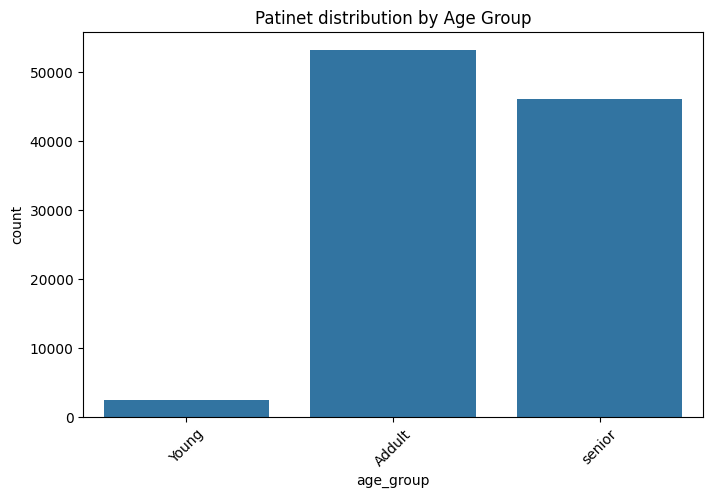

In [87]:
plt.figure(figsize=(8,5))
sns.countplot(
x="age_group",
data=df
)

plt.title(
'Patinet distribution by Age Group'
)

plt.xticks(rotation=45)

plt.show()

In [62]:
numeric_cols = df.select_dtypes(
include=np.number
).columns

In [63]:
quality_report = pd.DataFrame({

"Rows":[df.shape[0]],

"Columns":[df.shape[1]],

"Missing Values":[df.isnull().sum()],

"Duplicates":[df.duplicated().sum()]
})

quality_report

,Rows,Columns,Missing Values,Duplicates
0,101766,48,id 0 encounter_id ...,0


In [96]:
before_after = pd.DataFrame({
"Metric": [
    "Rows",
    "Columns",
    "Missing Values",
    "Duplicate Rows",
],
"Before": [
    original_rows,
    original_columns,
    original_missing,
    original_duplicates
],
"After":[
    df.shape[0],
    df.shape[1],
    df.isnull().sum().sum(),
    df.duplicated().sum()

]


})

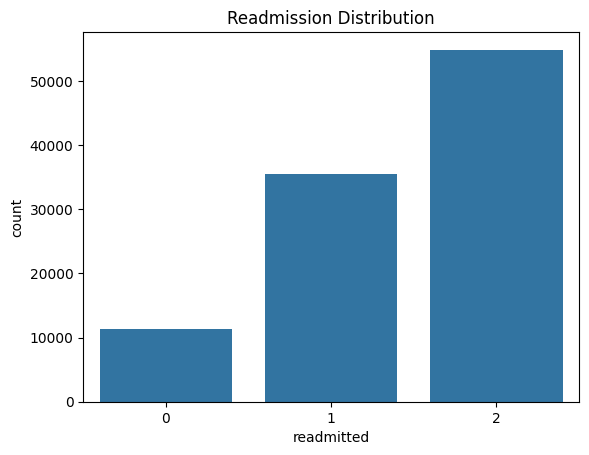

In [97]:
sns.countplot(x="readmitted", data=df)

plt.title("Readmission Distribution")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

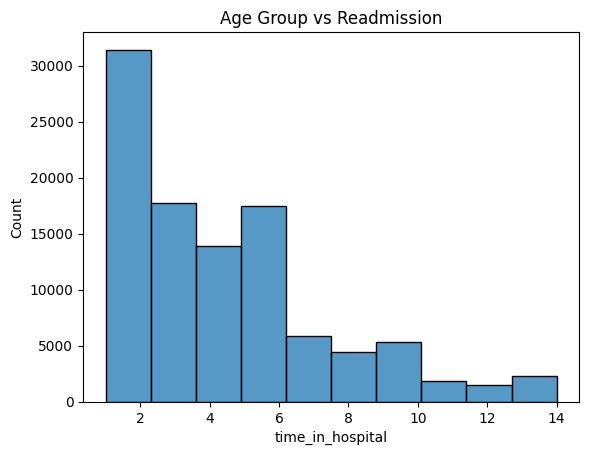

In [98]:
sns.histplot(
    df["time_in_hospital"],
    bins=10
)

plt.title("Age Group vs Readmission")
plt.show

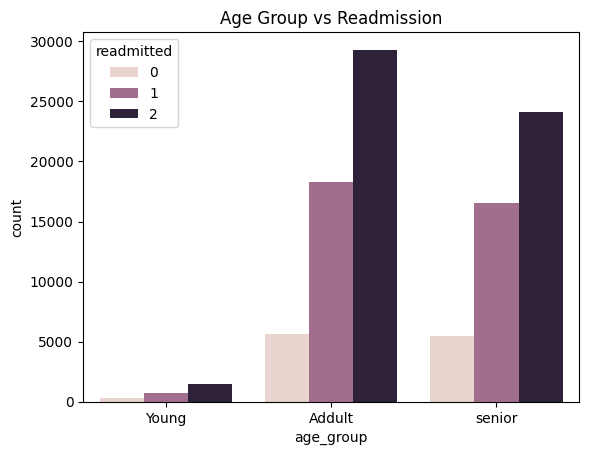

In [99]:
sns.countplot(
    x="age_group",
    hue="readmitted",
    data=df
)

plt.title("Age Group vs Readmission")
plt.show()

In [101]:
df.to_csv(
    "clean_diabetes_data.csv",
index=False
)

print(
"Clean dataset saved successfully"
)

Clean dataset saved successfully
